In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
#Read Data
#Tải Dữ Liệu
data = pd.read_csv("data.csv")
print("Đã tải dữ liệu từ data.csv.")

Đã tải dữ liệu từ data.csv.


In [3]:
data.count()

InvoiceNo      541909
StockCode      541909
Description    540455
Quantity       541909
InvoiceDate    541909
UnitPrice      541909
CustomerID     406829
Country        541909
dtype: int64

In [4]:
# loại bỏ CustomerID bị NaN
data_not_nan = data[data['CustomerID'].notnull()]

# loại bỏ đơn hàng trả lại (Quantity âm)
data_not_nan = data_not_nan[data_not_nan['Quantity'] > 0]

# loại bỏ giá = 0
data_not_nan = data_not_nan[data_not_nan['UnitPrice'] > 0]

data_not_nan.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [5]:
# tính toán RFM
# tính R = Recency
# chuyển từ string sang date
data_not_nan['InvoiceDate'] = pd.to_datetime(data_not_nan['InvoiceDate'], format='%m/%d/%Y %H:%M')

# lấy ngày lớn nhất trong invoicedate + 1
# ngày snapshot - các ngày hóa đơn = R
import datetime
current_date = data_not_nan['InvoiceDate'].max() + datetime.timedelta(days=1)

# Tinh M - Moneytaryvalue
data_not_nan['TotalPay'] = data_not_nan['Quantity'] * data_not_nan['UnitPrice']
# group by CustomerID de tinh R, F, M

data_customers = data_not_nan.groupby(['CustomerID']).agg(
    {'InvoiceDate': lambda x: (current_date- x.max()).days,
    'InvoiceNo': 'nunique', 
    'TotalPay': 'sum'
    }
)

In [6]:
data_customers.head()

,InvoiceDate,InvoiceNo,TotalPay
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [7]:
data_customers.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalPay':'Monetary'}, inplace=True)

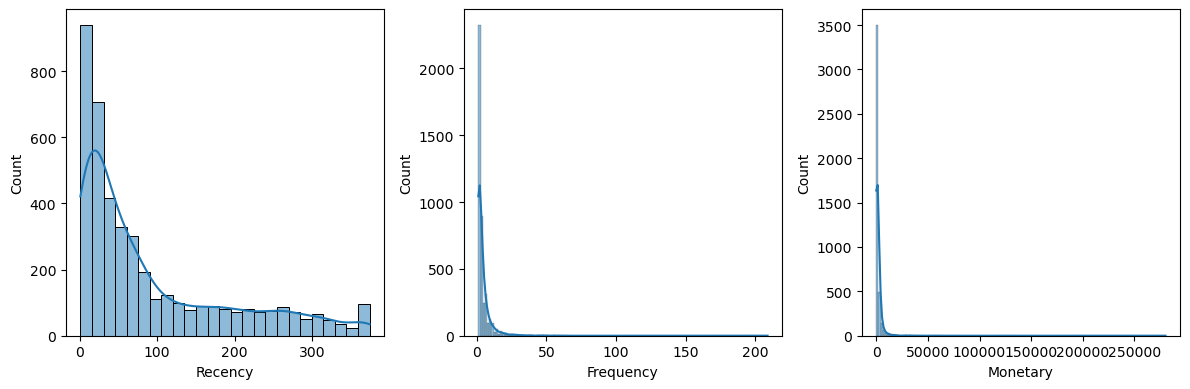

In [8]:
# Vẽ phân phối để kiểm tra
fig, ax = plt.subplots(1, 3, figsize=(12,4))

sns.histplot(data_customers['Recency'], kde=True, ax=ax[0])
sns.histplot(data_customers['Frequency'], kde=True, ax=ax[1])
sns.histplot(data_customers['Monetary'], kde=True, ax=ax[2])

plt.tight_layout() 
plt.show()

In [9]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_skewness(x):
    fig, ax = plt.subplots(1, 4, figsize=(15,4))
    sns.histplot(data_customers[x], kde=True, ax=ax[0]).set_title("Original")
    sns.histplot(np.log1p(data_customers[x]), kde=True, ax=ax[1]).set_title("Log1p")
    sns.histplot(np.sqrt(data_customers[x]), kde=True, ax=ax[2]).set_title("Square Root")
    sns.histplot(np.cbrt(data_customers[x]), kde=True, ax=ax[3]).set_title("Cube Root")
    plt.tight_layout()
    plt.show()

    print(data_customers[x].skew().round(4))
    print(np.log1p(data_customers[x]).skew().round(4))
    print(np.sqrt(data_customers[x]).skew().round(4))
    print(np.cbrt(data_customers[x]).skew().round(4)) 

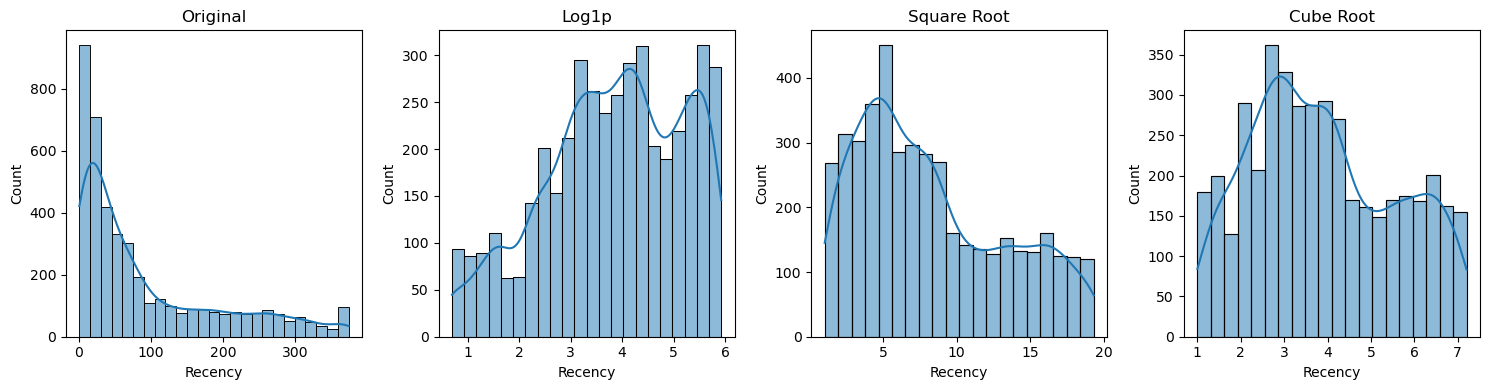

1.246
-0.3792
0.5887
0.2829


In [10]:
analyze_skewness('Recency')

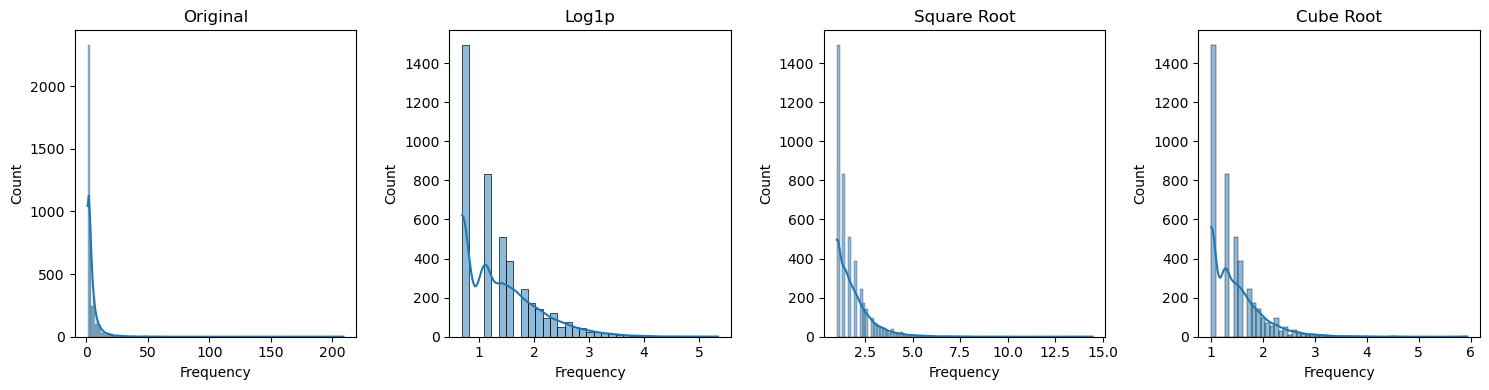

12.067
1.2087
3.024
1.9123


In [11]:
analyze_skewness('Frequency')

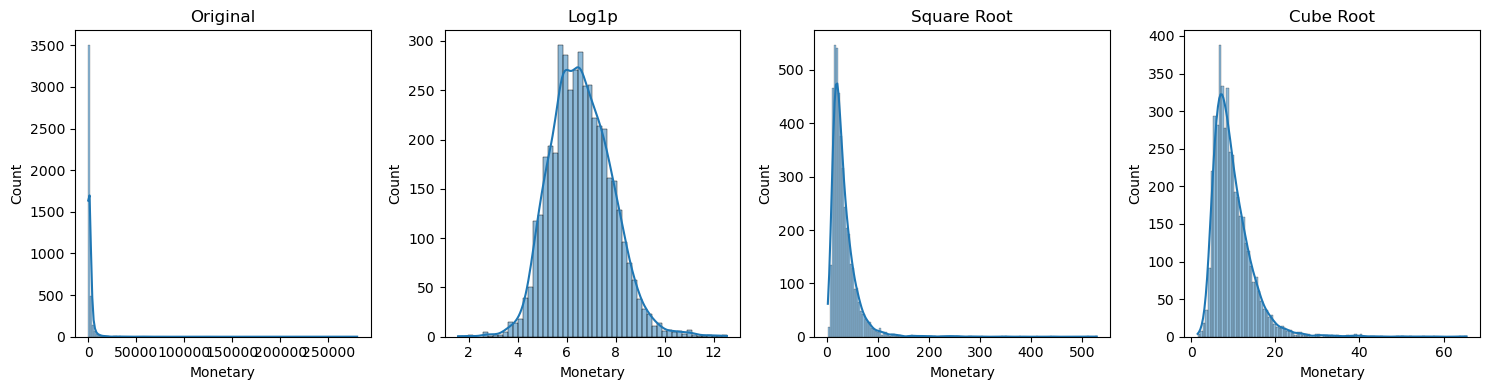

19.325
0.3936
5.8878
3.001


In [12]:
analyze_skewness('Monetary')

In [13]:
# XỬ LÝ OUTLIERS 
print("Trước khi xử lý Outliers")
print(data_customers[['Recency', 'Frequency', 'Monetary']].max())

# Giữ lại dữ liệu từ 1% đến 99%
lower_bound = 0.01 
upper_bound = 0.99 

for col in ['Recency', 'Frequency', 'Monetary']:
    quantiles = data_customers[col].quantile([lower_bound, upper_bound]).values
    # Ép các giá trị vượt ngưỡng về bằng đúng giá trị ở biên 1% và 99%
    data_customers[col] = np.clip(data_customers[col], quantiles[0], quantiles[1])

print("Sau khi xử lý Outliers")
print(data_customers[['Recency', 'Frequency', 'Monetary']].max())

Trước khi xử lý Outliers
Recency         374.00
Frequency       209.00
Monetary     280206.02
dtype: float64
Sau khi xử lý Outliers
Recency        369.0000
Frequency       30.0000
Monetary     19880.9957
dtype: float64


In [14]:
data_customers_t = pd.DataFrame()

# Áp dụng các phép biến đổi tối ưu nhất 
data_customers_t['Recency'] = np.cbrt(data_customers['Recency'])
data_customers_t['Frequency'] = np.log1p(data_customers['Frequency'])
data_customers_t['Monetary'] = np.log1p(data_customers['Monetary'])

data_customers_t.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,6.882389,0.693147,9.897570
12347.0,1.259921,2.079442,8.368925
12348.0,4.217163,1.609438,7.494564
12349.0,2.668402,0.693147,7.472245
12350.0,6.767899,0.693147,5.815324
12352.0,3.301927,2.197225,7.826858
12353.0,5.886765,0.693147,4.499810
12354.0,6.144634,0.693147,6.985087
12355.0,5.981424,0.693147,6.132096


In [15]:
# tiến hành scale dữ liệu
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(data_customers_t)
data_customers_t = scaler.transform(data_customers_t)
data_customers_t

array([[ 1.80079678, -0.97409971,  2.72600503],
       [-1.58715333,  1.1109521 ,  1.46612   ],
       [ 0.19480253,  0.40404457,  0.74548495],
       ...,
       [-1.14120136, -0.36426115, -1.15582477],
       [-1.38982256,  2.24466029,  0.87172123],
       [-0.23529351,  0.0684262 ,  0.76363509]], shape=(4338, 3))

In [16]:
pd.DataFrame(data_customers_t).head()

,0,1,2
0,1.800797,-0.974100,2.726005
1,-1.587153,1.110952,1.466120
2,0.194803,0.404045,0.745485
3,-0.738440,-0.974100,0.727090
4,1.731809,-0.974100,-0.638518


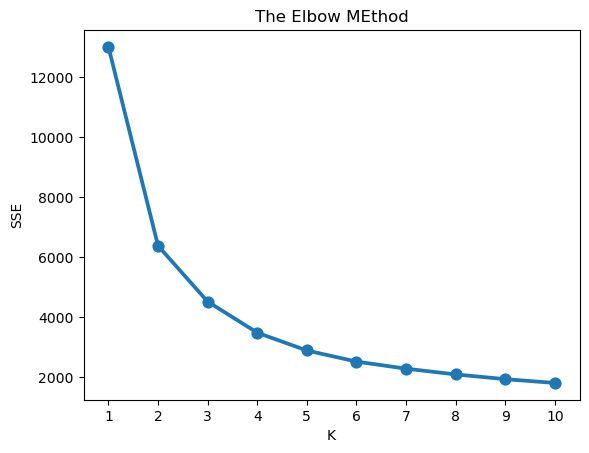

In [17]:
# chọn số cụm bằng Elbow
from sklearn.cluster import KMeans

sse = {}
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state =42, n_init=10)
    kmeans.fit(data_customers_t)
    sse[k] = kmeans.inertia_

plt.title('The Elbow MEthod')
plt.xlabel('K')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Chạy vòng lặp cho K từ 2 đến 5
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(data_customers_t)
    
    # Tính điểm
    sil_score = silhouette_score(data_customers_t, model.labels_)
    
    print(f"Silhouette score K={k}: {sil_score}")

Silhouette score K=2: 0.42420756561780576
Silhouette score K=3: 0.35623362118945495
Silhouette score K=4: 0.3429246293095589
Silhouette score K=5: 0.3413579963774


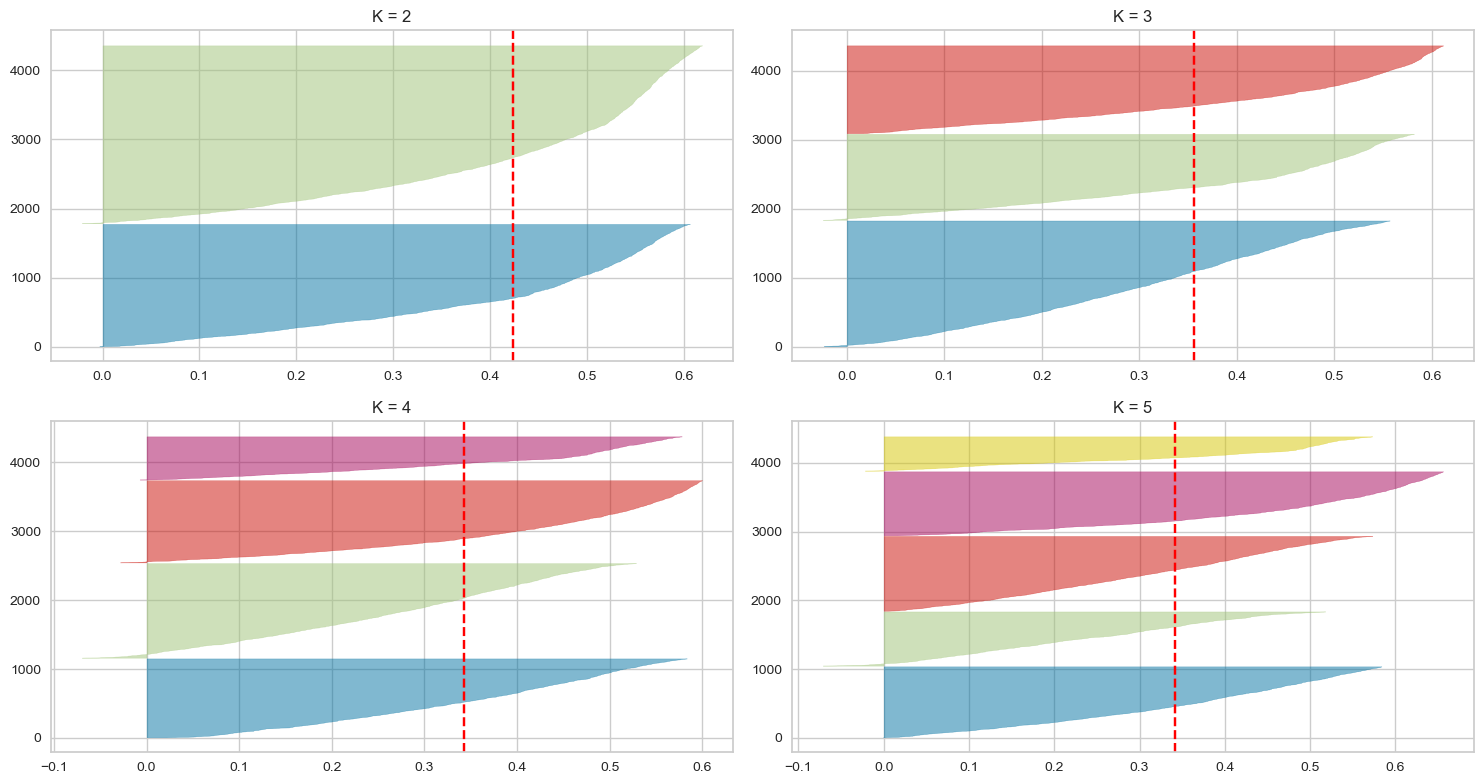

In [19]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(15,8))

for i in [2, 3, 4, 5]:
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(data_customers_t) 
    
    ax[q-1][mod].set_title(f"K = {i}", fontsize=12) 
    ax[q-1][mod].set_xlabel("") 
    ax[q-1][mod].set_ylabel("") 

plt.tight_layout()
plt.show() 


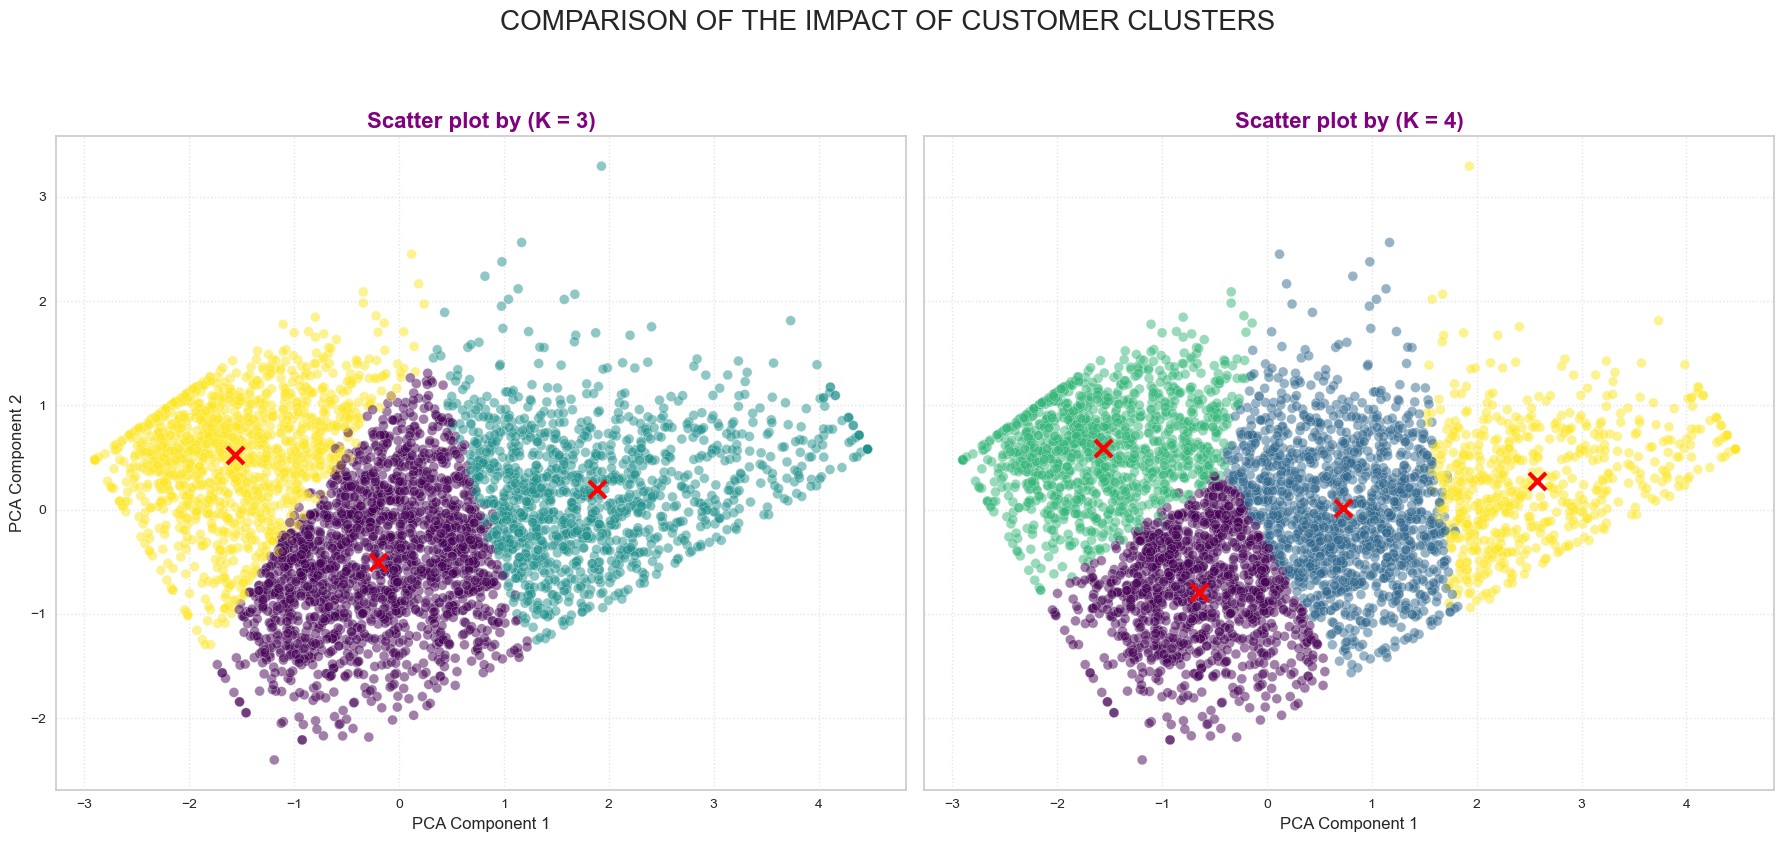

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(data_customers_t)

def plot_pca_comparison_final(pca_data, scaled_data, k_values=[3, 4]):
    fig, ax = plt.subplots(1, len(k_values), figsize=(18, 8), sharey=True)
    
    colors = ['purple', 'blue', 'yellow', 'green']
    
    for i, k in enumerate(k_values):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(scaled_data)
        
        # Tính toán tâm cụm (Centroids) )
        centroids_pca = pca.transform(model.cluster_centers_)
        
        # C. Vẽ các điểm dữ liệu (Scatter Plot)
        scatter = ax[i].scatter(pca_data[:, 0], pca_data[:, 1], c=labels, 
                                cmap='viridis', alpha=0.5, edgecolor='white', s=50, zorder=2)

        # VẼ TÂM CỤM (CENTROIDS) 
        ax[i].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
                      marker='x', s=150, linewidths=3, color='red', zorder=10, label='Centroids')

        ax[i].set_title(f'Scatter plot by (K = {k})', fontsize=16, fontweight='bold', color='purple')
        ax[i].set_xlabel('PCA Component 1', fontsize=12)
        if i == 0:
            ax[i].set_ylabel('PCA Component 2', fontsize=12)
    
        ax[i].grid(True, linestyle=':', alpha=0.5)

    
    plt.suptitle("COMPARISON OF THE IMPACT OF CUSTOMER CLUSTERS ", fontsize=20, y=1.05)
    plt.tight_layout()
    plt.show()

plot_pca_comparison_final(df_pca, data_customers_t, [3, 4])

In [21]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(data_customers_t)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [22]:
data_customers['Cluster'] = model.labels_
data_customers.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,19880.9957,2
12347.0,2,7,4310.0000,1
12348.0,75,4,1797.2400,1
12349.0,19,1,1757.5500,0
12350.0,310,1,334.4000,2


In [23]:
data_customers.groupby('Cluster').agg(
    {
        'Recency':'mean',
        'Frequency':'mean',
        'Monetary': 'mean'
    }
).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,45.64,2.19,688.55
1,26.72,9.23,4102.27
2,225.13,1.43,417.77


In [24]:
cluster_labels = {
    0: 'Khách hàng phổ thông',
    1: 'Khách hàng cao cấp',
    2: 'Khách hàng rời bỏ'
}

data_customers['Segment'] = data_customers['Cluster'].map(cluster_labels)

In [25]:
data_customers.head(10)

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,19880.9957,2,Khách hàng rời bỏ
12347.0,2,7,4310.0000,1,Khách hàng cao cấp
12348.0,75,4,1797.2400,1,Khách hàng cao cấp
12349.0,19,1,1757.5500,0,Khách hàng phổ thông
12350.0,310,1,334.4000,2,Khách hàng rời bỏ
12352.0,36,8,2506.0400,1,Khách hàng cao cấp
12353.0,204,1,89.0000,2,Khách hàng rời bỏ
12354.0,232,1,1079.4000,2,Khách hàng rời bỏ
12355.0,214,1,459.4000,2,Khách hàng rời bỏ


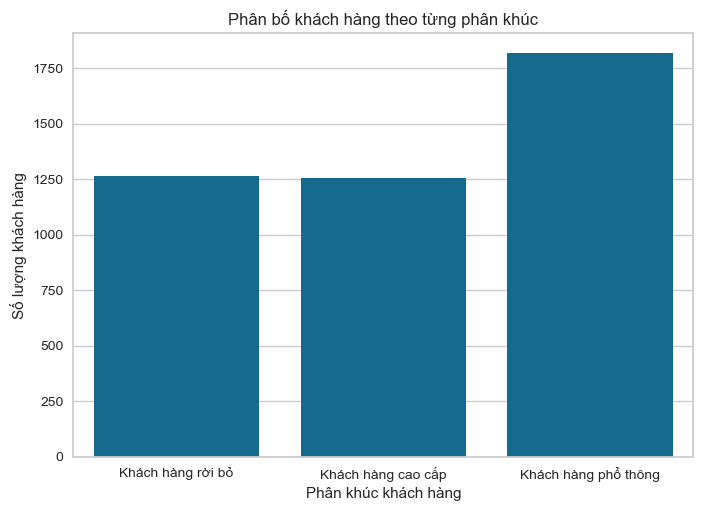

In [26]:
sns.countplot(x='Segment', data=data_customers)

plt.title("Phân bố khách hàng theo từng phân khúc")
plt.xlabel("Phân khúc khách hàng")
plt.ylabel("Số lượng khách hàng")

plt.show()

In [27]:
data_customers['Segment'].value_counts()

Segment
Khách hàng phổ thông    1816
Khách hàng rời bỏ       1265
Khách hàng cao cấp      1257
Name: count, dtype: int64

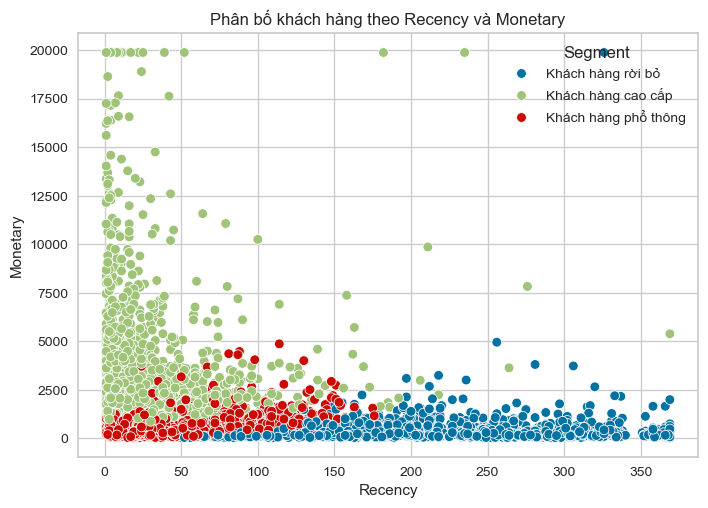

In [28]:
sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Segment',
    data=data_customers
)

plt.title("Phân bố khách hàng theo Recency và Monetary")
plt.show()

In [29]:
rfm_mean = data_customers.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

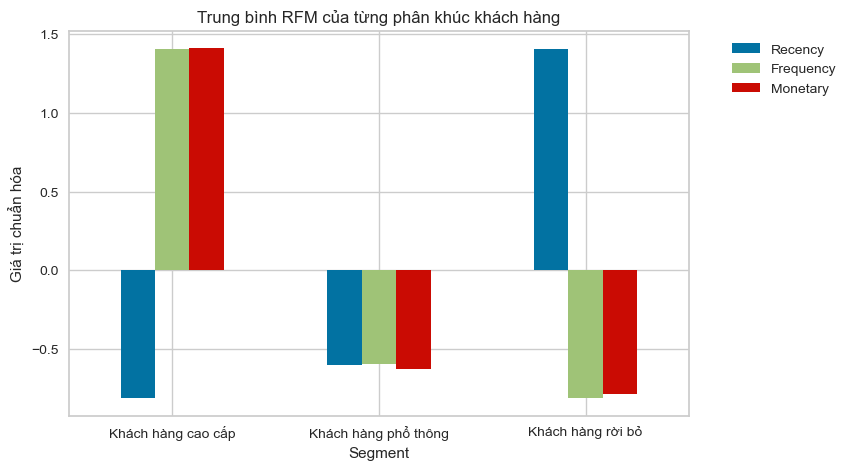

In [30]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler_plot = StandardScaler() 

rfm_scaled_mean = pd.DataFrame(
    scaler_plot.fit_transform(rfm_mean),
    columns=rfm_mean.columns,
    index=rfm_mean.index
)

rfm_scaled_mean.plot(kind='bar', figsize=(8,5))
plt.title("Trung bình RFM của từng phân khúc khách hàng")
plt.ylabel("Giá trị chuẩn hóa")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()


In [31]:
wrap_up_final = data_customers.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# 2. Hàm chuyển đổi số liệu thành chữ (Low, Normal, High)
def get_characteristic_table(df):
    char_df = df.copy()
    for col in ['Recency', 'Frequency', 'Monetary']:
        desc_col = []
        q1, q2 = df[col].quantile([0.33, 0.66])
        for val in df[col]:
            if val <= q1: label = "Low"
            elif val <= q2: label = "Normal"
            else: label = "High"
            
            if col == 'Recency':
                label = "Average" if label == "Normal" else ("Recent" if label == "Low" else "Long time")
            else:
                label = label.capitalize()
            desc_col.append(label)
        char_df[col] = desc_col
    return char_df

char_table = get_characteristic_table(wrap_up_final)

# 3. Thêm cột Customer Define và Chiến lược Marketing
char_table['Customer Define'] = char_table.index

strategy_dict = {
    'khách hàng cao cấp': 'Loyalty Program & Exclusive Offers',
    'khách hàng phổ thông': 'Cross-sell & Retention Campaigns',
    'khách hàng rời bỏ': 'Win-back Promotions & Surveys'
}
char_table['Marketing Strategy'] = char_table.index.str.lower().map(strategy_dict)

# 4. Xoay ngang bảng (Transpose) và lọc lấy đúng 5 dòng bạn cần
final_table = char_table.T
ordered_rows = [
    'Customer Define', 
    'Recency', 
    'Frequency', 
    'Monetary', 
    'Marketing Strategy'
]
final_table = final_table.reindex(ordered_rows).reset_index()

# 5. Tự động đánh số Cluster 0, 1, 2 cho khớp với tên
segment_map = {
    0: 'Khách hàng phổ thông',
    1: 'Khách hàng cao cấp',
    2: 'khách hàng rời bỏ'
}
reverse_map = {v.lower(): k for k, v in segment_map.items()}

new_columns = ['objective']
for col in final_table.columns[1:]:
    cluster_num = reverse_map.get(col.lower(), col)
    new_columns.append(f'Cluster {cluster_num}')

final_table.columns = new_columns

# 6. Hàm tô màu tự động giống form mẫu
def highlight_cells(val):
    val_str = str(val).lower()
    if val_str in ['high', 'recent', 'very high']:
        return 'background-color: #c8e6c9; color: #2e7d32; font-weight: bold;'
    elif val_str in ['normal', 'average']:
        return 'background-color: #fff9c4; color: #f57f17; font-weight: bold;'
    elif val_str in ['low', 'long time', 'very low']:
        return 'background-color: #ffcdd2; color: #c62828; font-weight: bold;'
    return 'background-color: white; color: black;'

def style_wrap_up(styler):
    styler.set_properties(**{
        'text-align': 'center', 
        'border': '1px solid #d3d3d3', 
        'padding': '12px 8px', 
        'font-family': 'Arial, sans-serif'
    })
    styler.set_table_styles([
        {'selector': 'thead th', 'props': [('background-color', '#9a476a'), ('color', 'white'), ('font-size', '15px'), ('font-weight', 'bold'), ('border', '1px solid #d3d3d3')]},
        {'selector': 'thead th:first-child', 'props': [('background-color', '#3a5068')]}
    ])
    styler.map(lambda _: 'background-color: #3a5068; color: white; font-weight: bold; text-align: left; border-right: 2px solid white;', subset=['objective'])
    cluster_cols = [col for col in final_table.columns if col != 'objective']
    styler.map(highlight_cells, subset=cluster_cols)
    styler.hide(axis='index') 
    return styler

# Xuất bảng ra màn hình
display(final_table.style.pipe(style_wrap_up))

objective,Cluster 1,Cluster 0,Cluster 2
Customer Define,Khách hàng cao cấp,Khách hàng phổ thông,Khách hàng rời bỏ
Recency,Recent,Average,Long time
Frequency,High,Normal,Low
Monetary,High,Normal,Low
Marketing Strategy,Loyalty Program & Exclusive Offers,Cross-sell & Retention Campaigns,Win-back Promotions & Surveys


In [32]:
# lưu mô hình
joblib.dump(scaler, 'scaler_rfm_E-Commerce.pkl')
joblib.dump(model, 'kmeans_rfm_model_E-Commerce.pkl') 
print("lưu thành công !")

lưu thành công !
